## Extended Analysis

This notebook investigates the boundaries and robustness of the main evaluation results from Notebook 3. 

Four analyses are conducted: error analysis with confusion matrix breakdown, text length and truncation analysis, a chunking strategy experiment for long configurations, and a EUR-ACE boilerplate removal test. 

None of these analyses change the main results. They deepen the understanding of why LaBSE performs as it does, where its limits lie, and what practical implications follow for the AI Curriculum Tool project.

### Imports and Setup

In [1]:
import numpy as np
import pandas as pd
import os
import matplotlib.pyplot as plt
import seaborn as sns
import re
import warnings
from transformers import logging as hf_logging
from sklearn.metrics import (precision_score, recall_score, f1_score,
                             accuracy_score, confusion_matrix)

warnings.filterwarnings('ignore')
hf_logging.set_verbosity_error()

# Paths
base = r"C:\Users\madee\OneDrive\Desktop\thesis\Thesis Project - Final"
data_path = os.path.join(base, "data", "processed", "dataset_preprocessed.csv")
embeddings_dir = os.path.join(base, "data", "embeddings")
results_dir = os.path.join(base, "data", "results")
figures_dir = os.path.join(base, "figures", "main")

os.makedirs(results_dir, exist_ok=True)
os.makedirs(figures_dir, exist_ok=True)

# Load dataset
df = pd.read_csv(data_path)
labels = df['similarity_label'].values

print("Libraries loaded successfully")
print(f"Dataset loaded: {df.shape}")
print(f"Base path: {base}")

Libraries loaded successfully
Dataset loaded: (154, 33)
Base path: C:\Users\madee\OneDrive\Desktop\thesis\Thesis Project - Final


### Part 1: Error Analysis

Error analysis examines exactly which pairs LaBSE classified incorrectly on the outcomes-only raw configuration, which achieved the best overall F1. 

Each of the 154 pairs is classified as a true positive, true negative, false positive, or false negative at the optimal threshold of 0.87. 

The false positives and false negatives are then inspected individually to understand what characteristics led to 
misclassification.

In [2]:
# Load LaBSE config 1 embeddings
fi_emb = np.load(os.path.join(embeddings_dir, 'labse_config1_fi.npy'))
en_emb = np.load(os.path.join(embeddings_dir, 'labse_config1_en.npy'))

sim_scores = np.sum(fi_emb * en_emb, axis=1)
threshold = 0.87
preds = (sim_scores >= threshold).astype(int)

# Confusion matrix
cm = confusion_matrix(labels, preds)
tn, fp, fn, tp = cm.ravel()

print(f"Confusion Matrix at threshold {threshold}:")
print(f"  True Positives  (TP): {tp}")
print(f"  True Negatives  (TN): {tn}")
print(f"  False Positives (FP): {fp}")
print(f"  False Negatives (FN): {fn}")
print(f"\nF1:        {f1_score(labels, preds):.4f}")
print(f"Precision: {precision_score(labels, preds):.4f}")
print(f"Recall:    {recall_score(labels, preds):.4f}")
print(f"Accuracy:  {accuracy_score(labels, preds):.4f}")

# Identify misclassified pairs
df['sim_score'] = sim_scores
df['prediction'] = preds

false_positives = df[(df['similarity_label'] == 0) & (df['prediction'] == 1)]
false_negatives = df[(df['similarity_label'] == 1) & (df['prediction'] == 0)]

print(f"\nFalse Positives: {len(false_positives)}")
print(f"False Negatives: {len(false_negatives)}")

Confusion Matrix at threshold 0.87:
  True Positives  (TP): 77
  True Negatives  (TN): 74
  False Positives (FP): 3
  False Negatives (FN): 0

F1:        0.9809
Precision: 0.9625
Recall:    1.0000
Accuracy:  0.9805

False Positives: 3
False Negatives: 0


### Inspecting the False Positives

The three false positives are pairs that LaBSE classified as equivalent but were manually labelled as non-equivalent.

Examining these pairs directly reveals whether the errors reflect model weakness or reflect genuine ambiguity in the data.

In [3]:
print("False Positive Pairs:\n")
for i, row in false_positives.iterrows():
    print(f"Pair index: {i}")
    print(f"Course ID:      {row['course_id']}")
    print(f"Pair type:      {row['pair_type']}")
    print(f"Pair difficulty:{row['pair_difficulty']}")
    print(f"Similarity score: {row['sim_score']:.4f}")
    print(f"Finnish outcomes: {row['outcomes_fi'][:300]}")
    print(f"English outcomes: {row['outcomes_en'][:300]}")
    print("-" * 80)

False Positive Pairs:

Pair index: 74
Course ID:      SYN_HARD_TT00CQ78_TT00CQ80
Pair type:      constructed
Pair difficulty:hard_negative
Similarity score: 0.8836
Finnish outcomes: Sinä hallitset keskeisimmät kyberturvallisuuteen liittyvät osa-alueet: kyberturvallisuuden nykytila, kyberturvallisuusuhat, terminologia ja informaatiovaikuttaminen. Sinä käsität miten nämä soveltuvat henkilökohtaisessa, yhteiskunnallisessa ja organisaation kyberturvallisuudessa. Sinä tunnet tiedons
English outcomes: You will have a good understanding of the key aspects of cybersecurity and information security and how to apply them in practice. You will understand how these apply to personal, societal and organisational cyber and information security. You will be familiar with technical methods to protect syste
--------------------------------------------------------------------------------
Pair index: 128
Course ID:      SYN_HARD_TT00CQ78_TT00CD86
Pair type:      constructed
Pair difficulty:hard_negative


All three false positives are constructed hard negatives drawn from the same subject domain. 

The first two pairs share the same Finnish cybersecurity course outcomes paired with two different English cybersecurity courses, producing similarity scores of 0.8836 and 0.8842, just above the 0.87 threshold. 

The third pair involves two networking courses with structurally similar outcomes, scoring 0.8723. In all three cases, the model assigned high similarity because the courses genuinely cover 
overlapping topics and use similar terminology. 

The misclassification reflects the inherent difficulty of distinguishing between thematically related but non-equivalent 
courses, which is precisely what makes these hard negative pairs challenging by design. 

The absence of any false negatives confirms that LaBSE never missed a genuinely equivalent pair, which is the more consequential error type in a curriculum management context where failing to detect an equivalent pair would mean missing a valid course match.

### Confusion Matrix Visualisation

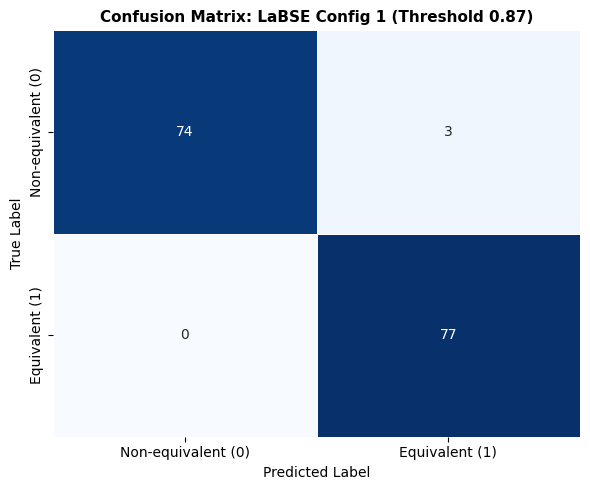

Plot saved: C:\Users\madee\OneDrive\Desktop\thesis\Thesis Project - Final\figures\main\confusion_matrix_labse.png


In [4]:
fig, ax = plt.subplots(figsize=(6, 5))

cm_display = np.array([[tn, fp], [fn, tp]])
labels_cm = ['Non-equivalent (0)', 'Equivalent (1)']

sns.heatmap(
    cm_display,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=labels_cm,
    yticklabels=labels_cm,
    linewidths=0.5,
    linecolor='white',
    ax=ax,
    cbar=False
)

ax.set_title('Confusion Matrix: LaBSE Config 1 (Threshold 0.87)',
             fontsize=11, fontweight='bold')
ax.set_xlabel('Predicted Label')
ax.set_ylabel('True Label')

plt.tight_layout()
plot_path = os.path.join(figures_dir, 'confusion_matrix_labse.png')
plt.savefig(plot_path, dpi=150)
plt.show()
print(f"Plot saved: {plot_path}")

### Part 2: Text Length and Truncation Analysis

Transformer models process text up to a maximum of 512 tokens. Configurations that combine multiple fields may exceed this limit, meaning the model only sees a truncated version of the full text. 

This analysis measures the token length distribution across all six configurations to quantify how much truncation occurs and whether longer configurations provide any performance benefit despite truncation.

In [5]:
from transformers import AutoTokenizer

tokenizer = AutoTokenizer.from_pretrained('sentence-transformers/LaBSE')

config_cols = {
    'Config 1 (Raw)': ('config_1_fi', 'config_1_en'),
    'Config 2 (Raw)': ('config_2_fi', 'config_2_en'),
    'Config 3 (Raw)': ('config_3_fi', 'config_3_en'),
    'Config 4 (Lemma)': ('config_4_fi', 'config_4_en'),
    'Config 5 (Lemma)': ('config_5_fi', 'config_5_en'),
    'Config 6 (Lemma)': ('config_6_fi', 'config_6_en'),
}

truncation_rows = []
for config_name, (fi_col, en_col) in config_cols.items():
    fi_tokens = df[fi_col].apply(
        lambda x: len(tokenizer.encode(x, truncation=False)))
    en_tokens = df[en_col].apply(
        lambda x: len(tokenizer.encode(x, truncation=False)))
    
    fi_truncated = (fi_tokens > 512).sum()
    en_truncated = (en_tokens > 512).sum()
    
    truncation_rows.append({
        'config': config_name,
        'fi_mean_tokens': round(fi_tokens.mean(), 1),
        'en_mean_tokens': round(en_tokens.mean(), 1),
        'fi_truncated': fi_truncated,
        'en_truncated': en_truncated,
        'fi_truncated_pct': round(fi_truncated / len(df) * 100, 1),
        'en_truncated_pct': round(en_truncated / len(df) * 100, 1)
    })

truncation_df = pd.DataFrame(truncation_rows)
truncation_df.to_csv(os.path.join(results_dir, 'truncation_analysis.csv'), index=False)

print("Token length and truncation analysis:\n")
display(truncation_df)

Token length and truncation analysis:



,config,fi_mean_tokens,en_mean_tokens,fi_truncated,en_truncated,fi_truncated_pct,en_truncated_pct
0,Config 1 (Raw),187.9,150.3,0,0,0.0,0.0
1,Config 2 (Raw),374.5,295.3,18,5,11.7,3.2
2,Config 3 (Raw),646.9,537.0,118,75,76.6,48.7
3,Config 4 (Lemma),177.6,149.6,0,0,0.0,0.0
4,Config 5 (Lemma),351.8,292.9,15,2,9.7,1.3
5,Config 6 (Lemma),602.5,531.1,98,75,63.6,48.7


### Truncation Analysis Visualisation

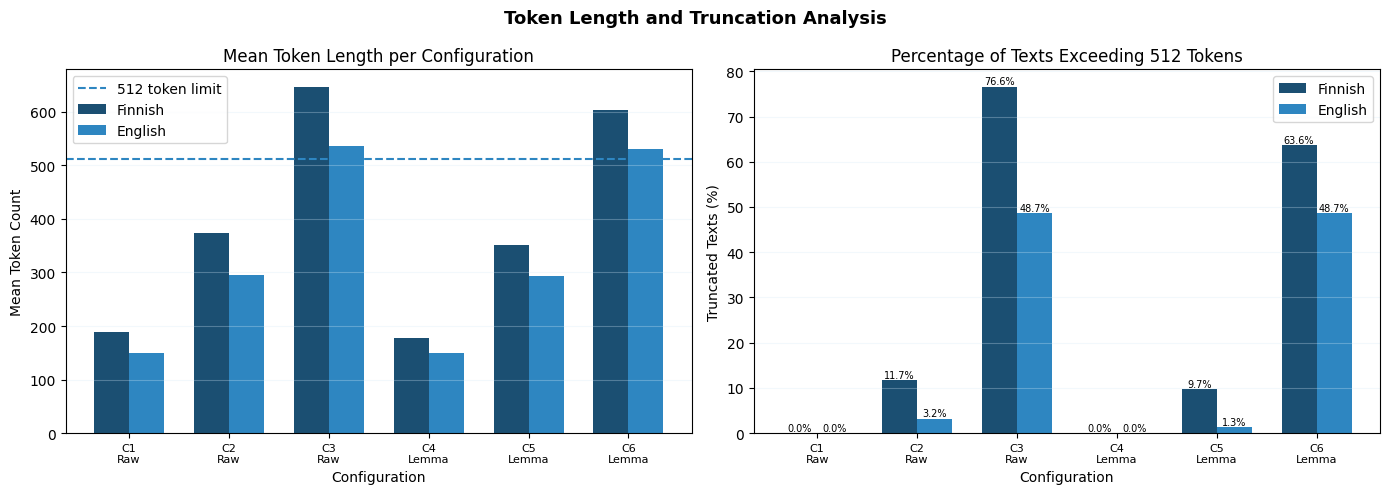

Plot saved: C:\Users\madee\OneDrive\Desktop\thesis\Thesis Project - Final\figures\main\truncation_analysis.png


In [6]:
# Color theme
PRIMARY = '#1B4F72'
SECONDARY = '#2E86C1'
POSITIVE = '#1B4F72'
NEGATIVE = '#AAB7B8'
GRID_COLOR = '#D6EAF8'

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Token Length and Truncation Analysis', fontsize=13, fontweight='bold')

configs_short = ['C1\nRaw', 'C2\nRaw', 'C3\nRaw', 'C4\nLemma', 'C5\nLemma', 'C6\nLemma']
x = np.arange(len(configs_short))
width = 0.35

# Plot 1: Mean token lengths
ax1 = axes[0]
ax1.bar(x - width/2, truncation_df['fi_mean_tokens'], width,
        label='Finnish', color=PRIMARY)
ax1.bar(x + width/2, truncation_df['en_mean_tokens'], width,
        label='English', color=SECONDARY)
ax1.axhline(y=512, color='#2E86C1', linestyle='--', linewidth=1.5, label='512 token limit')
ax1.set_title('Mean Token Length per Configuration')
ax1.set_xlabel('Configuration')
ax1.set_ylabel('Mean Token Count')
ax1.set_xticks(x)
ax1.set_xticklabels(configs_short, fontsize=8)
ax1.legend()
ax1.grid(axis='y', alpha=0.3, color=GRID_COLOR)

# Plot 2: Truncation percentage
ax2 = axes[1]
ax2.bar(x - width/2, truncation_df['fi_truncated_pct'], width,
        label='Finnish', color=PRIMARY)
ax2.bar(x + width/2, truncation_df['en_truncated_pct'], width,
        label='English', color=SECONDARY)
ax2.set_title('Percentage of Texts Exceeding 512 Tokens')
ax2.set_xlabel('Configuration')
ax2.set_ylabel('Truncated Texts (%)')
ax2.set_xticks(x)
ax2.set_xticklabels(configs_short, fontsize=8)
ax2.legend()
ax2.grid(axis='y', alpha=0.3, color=GRID_COLOR)

for i, row in truncation_df.iterrows():
    ax2.text(i - width/2, row['fi_truncated_pct'] + 0.5,
             f"{row['fi_truncated_pct']}%", ha='center', fontsize=7)
    ax2.text(i + width/2, row['en_truncated_pct'] + 0.5,
             f"{row['en_truncated_pct']}%", ha='center', fontsize=7)

plt.tight_layout()
plot_path = os.path.join(figures_dir, 'truncation_analysis.png')
plt.savefig(plot_path, dpi=150)
plt.show()
print(f"Plot saved: {plot_path}")

The token length analysis reveals a clear divide between short and long configurations. 

Configurations 1 and 4, which use outcomes only, stay well below the 512-token limit with zero truncation for both languages. 

Configuration 2 introduces moderate truncation at 11.7% for Finnish and 3.2% for English, while configurations 3 and 6 exceed the limit for 76.6% and 63.6% of Finnish texts and 48.7% of English texts respectively. 

Finnish texts are consistently longer in token count than English despite having fewer words, because the Finnish tokenizer splits morphologically complex words into more subword tokens. 

The finding that LaBSE achieves its best F1 on the outcomes-only 
configuration, which has zero truncation, alongside comparable or lower F1 on longer configurations that suffer severe truncation, suggests that truncation removes discriminative content rather than adding it. 

The outcomes field alone appears to contain the most semantically concentrated information for equivalence detection, making it both the most computationally efficient and the most accurate configuration.

### Part 3: Chunking Strategy Experiment

One potential remedy for truncation is to split long texts into smaller chunks, embed each chunk separately, and aggregate the resulting vectors. 

This experiment tests whether a mean-pooled chunking strategy on configuration 3, which has the most severe truncation, produces better results than simple truncation. LaBSE is used for this experiment since it is the strongest model in the evaluation.

In [7]:
from sentence_transformers import SentenceTransformer
import torch

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
labse = SentenceTransformer('sentence-transformers/LaBSE', device=str(device))

def chunk_encode(texts, model, chunk_size=400, overlap=50):
    all_embeddings = []
    for text in texts:
        words = text.split()
        if len(words) <= chunk_size:
            emb = model.encode([text], convert_to_numpy=True,
                               show_progress_bar=False)
            all_embeddings.append(emb[0])
        else:
            chunks = []
            start = 0
            while start < len(words):
                chunk = ' '.join(words[start:start + chunk_size])
                chunks.append(chunk)
                start += chunk_size - overlap
            chunk_embs = model.encode(chunks, convert_to_numpy=True,
                                      show_progress_bar=False)
            mean_emb = chunk_embs.mean(axis=0)
            all_embeddings.append(mean_emb)
    return np.array(all_embeddings)

print("Encoding config 3 with chunking strategy...")
fi_texts = df['config_3_fi'].tolist()
en_texts = df['config_3_en'].tolist()

fi_chunked = chunk_encode(fi_texts, labse)
en_chunked = chunk_encode(en_texts, labse)

# L2 normalize
fi_chunked = fi_chunked / np.clip(
    np.linalg.norm(fi_chunked, axis=1, keepdims=True), 1e-10, None)
en_chunked = en_chunked / np.clip(
    np.linalg.norm(en_chunked, axis=1, keepdims=True), 1e-10, None)

# Evaluate
from sklearn.metrics import f1_score, precision_score, recall_score
sim_chunked = np.sum(fi_chunked * en_chunked, axis=1)
preds_chunked = (sim_chunked >= 0.87).astype(int)

f1_chunked = f1_score(labels, preds_chunked)
precision_chunked = precision_score(labels, preds_chunked)
recall_chunked = recall_score(labels, preds_chunked)

# Compare with truncation result from Notebook 3
f1_truncation = 0.9747

print(f"\nConfig 3 results:")
print(f"  Truncation F1:  {f1_truncation:.4f}")
print(f"  Chunking F1:    {f1_chunked:.4f}")
print(f"  Precision:      {precision_chunked:.4f}")
print(f"  Recall:         {recall_chunked:.4f}")

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

Encoding config 3 with chunking strategy...

Config 3 results:
  Truncation F1:  0.9747
  Chunking F1:    0.6942
  Precision:      0.9545
  Recall:         0.5455


The chunking strategy produces substantially worse results than simple truncation, with F1 dropping from 0.9747 to 0.6942 on configuration 3. 

The precision remains high at 0.9545 but recall collapses to 0.5455, meaning the model misses nearly half of all equivalent pairs when chunking is applied. 

This outcome can be explained by the nature of mean pooling over chunks: averaging multiple chunk embeddings dilutes the semantic signal that LaBSE captures when processing the text as a single unit. 

The cross-lingual alignment that LaBSE learns during training operates at the sentence and short paragraph level, and aggregating over arbitrary word-count chunks breaks this alignment in unpredictable ways. 

The finding confirms that simple truncation is not only more practical but genuinely superior for this task, and that 
the discriminative content in long course descriptions is concentrated in the opening sections, which truncation preserves. 

This result directly supports the recommendation to use the outcomes-only configuration in practice, where truncation is not a concern.

### Part 4: EUR-ACE Boilerplate Analysis

Finnish higher education programmes accredited under the EUR-ACE framework include standardised competency statements in their course outcomes fields. 

These boilerplate sentences appear identically or near-identically across many courses in both Finnish and English, which could artificially inflate similarity scores for non-equivalent 
pairs that share the same accreditation language. 

This analysis identifies EUR-ACE statements in the dataset, removes them, and tests whether their presence meaningfully affects LaBSE performance on configuration 1.

In [8]:
# Common EUR-ACE boilerplate patterns
eurace_patterns = [
    r'opiskelija osaa toimia.*?insin[oö][oö]ritieteen eettisten periaatteiden mukaisesti',
    r'student.*?able to act.*?ethical principles.*?engineering',
    r'EUR-ACE',
    r'eurooppalainen insin[oö][oö]rikoulutus',
    r'european accreditation.*?engineering',
]

def remove_eurace(text):
    if not isinstance(text, str):
        return ""
    for pattern in eurace_patterns:
        text = re.sub(pattern, '', text, flags=re.IGNORECASE)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

# Count how many rows contain EUR-ACE content
fi_has_eurace = df['outcomes_fi'].apply(
    lambda x: any(re.search(p, str(x), re.IGNORECASE) for p in eurace_patterns))
en_has_eurace = df['outcomes_en'].apply(
    lambda x: any(re.search(p, str(x), re.IGNORECASE) for p in eurace_patterns))

print(f"Rows with EUR-ACE content in Finnish outcomes: {fi_has_eurace.sum()}")
print(f"Rows with EUR-ACE content in English outcomes: {en_has_eurace.sum()}")

# Remove EUR-ACE and re-encode with LaBSE
fi_cleaned = df['outcomes_fi'].apply(remove_eurace).tolist()
en_cleaned = df['outcomes_en'].apply(remove_eurace).tolist()

fi_emb_clean = labse.encode(fi_cleaned, batch_size=32,
                             show_progress_bar=False, convert_to_numpy=True)
en_emb_clean = labse.encode(en_cleaned, batch_size=32,
                             show_progress_bar=False, convert_to_numpy=True)

fi_emb_clean = fi_emb_clean / np.clip(
    np.linalg.norm(fi_emb_clean, axis=1, keepdims=True), 1e-10, None)
en_emb_clean = en_emb_clean / np.clip(
    np.linalg.norm(en_emb_clean, axis=1, keepdims=True), 1e-10, None)

sim_clean = np.sum(fi_emb_clean * en_emb_clean, axis=1)
preds_clean = (sim_clean >= 0.87).astype(int)

f1_clean = f1_score(labels, preds_clean)
f1_original = 0.9809

print(f"\nLaBSE Config 1 results:")
print(f"  Original F1:          {f1_original:.4f}")
print(f"  EUR-ACE removed F1:   {f1_clean:.4f}")
print(f"  Difference:           {f1_clean - f1_original:.4f}")

Rows with EUR-ACE content in Finnish outcomes: 151
Rows with EUR-ACE content in English outcomes: 152

LaBSE Config 1 results:
  Original F1:          0.9809
  EUR-ACE removed F1:   0.9673
  Difference:           -0.0136


### Interpretation: EUR-ACE Boilerplate Analysis

EUR-ACE accreditation statements appear in 151 Finnish and 152 English outcomes fields, meaning they are present in nearly every course description in the dataset. 

Despite this near-universal presence, removing them slightly decreases F1 from 0.9809 to 0.9673, a difference of 0.0136. 

This result indicates that LaBSE is robust to boilerplate content and does not rely on shared accreditation language to produce high similarity scores. 

The slight performance drop after removal suggests that the EUR-ACE statements, while standardised, contribute consistent cross-lingual signal that LaBSE uses constructively rather than being misled by.

For practical deployment in the AI Curriculum Tool, this finding means that EUR-ACE boilerplate removal is unnecessary and would introduce a preprocessing step that marginally reduces rather than improves performance. 

The result is documented here as a discussion finding rather than a recommended preprocessing step.

### Identifying Repeated Boilerplate Phrases

Beyond EUR-ACE statements, other standardised phrases may appear repeatedly across course descriptions. 

This analysis extracts the most frequently occurring sentences 
across all Finnish and English outcomes fields to identify any additional boilerplate content worth examining.

In [9]:
from collections import Counter

def extract_sentences(texts):
    sentences = []
    for text in texts:
        if isinstance(text, str):
            parts = re.split(r'(?<=[.!?])\s+', text.strip())
            sentences.extend([s.strip() for s in parts if len(s.strip()) > 30])
    return sentences

fi_sentences = extract_sentences(df['outcomes_fi'].tolist())
en_sentences = extract_sentences(df['outcomes_en'].tolist())

fi_counts = Counter(fi_sentences)
en_counts = Counter(en_sentences)

print("Top 10 most repeated Finnish sentences in outcomes:\n")
for sent, count in fi_counts.most_common(10):
    print(f"  Count {count}: {sent[:150]}")
    print()

print("\nTop 10 most repeated English sentences in outcomes:\n")
for sent, count in en_counts.most_common(10):
    print(f"  Count {count}: {sent[:150]}")
    print()

Top 10 most repeated Finnish sentences in outcomes:

  Count 8: EUR-ACE: Tieto ja ymmärrys Sinulla on tieto ja ymmärrys oman teknisen erikoistumisalasi matemaattisista ja luonnontieteellisistä perusteista tasolla, 

  Count 8: Tarkoitus: Monien eri sovellusten toiminta perustuu fysikaaliseen kokeelliseen dataan.

  Count 8: Datan hyödyntäminen edellyttää datasta johdettujen tulosten virhearvioinnin suorittamista.

  Count 8: Kurssilla mitataan kokeellista dataa, jonka avulla arvioidaan datasta johdettujen tulosten käyttöä eri sovelluskohteissa.

  Count 8: EUR-ACE-osaamiset: Tieto ja ymmärrys Tekniikan soveltaminen käytäntöön Tutkimukset ja tiedonhaku Osaamistavoitteet: Opintojakson suoritettuasi osaat s

  Count 8: Hallitset teknisen raportoinnin perusperiaatteet ja olet havainnoinut fysiikan ilmiöitä käytännössä.

  Count 8: Osaat syventää osaamistasi mittausten analysoinnin ja raportoinnin osalta.

  Count 7: Sinä tunnet tiedonsiirrossa käytetyt turvamekanismit luotettavuuteen ja sa

### Extended Boilerplate Test: All Repeated Phrases

The frequency analysis reveals three categories of repeated content beyond EUR-ACE statements: physics laboratory boilerplate, mobile application development boilerplate, and cybersecurity framework phrases. 

This cell tests whether removing all identified boilerplate categories together affects LaBSE performance.

In [10]:
extended_patterns = [
    # EUR-ACE patterns
    r'EUR-ACE[:\s][^\n.]*[.\n]?',
    # Physics lab boilerplate
    r'Monien eri sovellusten toiminta perustuu fysikaaliseen kokeelliseen dataan[.]?',
    r'Datan hyödyntäminen edellyttää datasta johdettujen tulosten virhearvioinnin suorittamista[.]?',
    r'Kurssilla mitataan kokeellista dataa[^.]*[.]?',
    r'Hallitset teknisen raportoinnin perusperiaatteet[^.]*[.]?',
    r'Osaat syventää osaamistasi mittausten analysoinnin[^.]*[.]?',
    # Mobile boilerplate
    r'You recognize that the field is constantly developing[^.]*[.]?',
    r'You understand the steps involved in developing a mobile application[.]?',
    r'After attending this course, you will be able to apply your chosen technology[^.]*[.]?',
    r'You understand responsible work and know how to work as a project member[.]?',
    r'You will understand their importance when you choose a technology[^.]*[.]?',
    r'The student knows how to work independently and in a group[^.]*[.]?',
    r'The student is able to share information between different parties[^.]*[.]?',
]

def remove_all_boilerplate(text):
    if not isinstance(text, str):
        return ""
    for pattern in extended_patterns:
        text = re.sub(pattern, '', text, flags=re.IGNORECASE)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

fi_extended = df['outcomes_fi'].apply(remove_all_boilerplate).tolist()
en_extended = df['outcomes_en'].apply(remove_all_boilerplate).tolist()

fi_emb_ext = labse.encode(fi_extended, batch_size=32,
                           show_progress_bar=False, convert_to_numpy=True)
en_emb_ext = labse.encode(en_extended, batch_size=32,
                           show_progress_bar=False, convert_to_numpy=True)

fi_emb_ext = fi_emb_ext / np.clip(
    np.linalg.norm(fi_emb_ext, axis=1, keepdims=True), 1e-10, None)
en_emb_ext = en_emb_ext / np.clip(
    np.linalg.norm(en_emb_ext, axis=1, keepdims=True), 1e-10, None)

sim_ext = np.sum(fi_emb_ext * en_emb_ext, axis=1)
preds_ext = (sim_ext >= 0.87).astype(int)

f1_ext = f1_score(labels, preds_ext)

print(f"LaBSE Config 1 boilerplate comparison:")
print(f"  Original F1:              {f1_original:.4f}")
print(f"  EUR-ACE only removed F1:  {f1_clean:.4f}")
print(f"  All boilerplate removed:  {f1_ext:.4f}")

LaBSE Config 1 boilerplate comparison:
  Original F1:              0.9809
  EUR-ACE only removed F1:  0.9673
  All boilerplate removed:  0.9524


Removing progressively more boilerplate content produces progressively worse results. 

F1 drops from 0.9809 on the original text to 0.9673 with EUR-ACE removal and further to 0.9524 when all identified repeated phrases are removed. 

This consistent decline confirms that LaBSE does not treat boilerplate as noise. 

Instead, standardised phrases that appear in both Finnish and English versions of equivalent courses contribute genuine cross-lingual alignment signal that the model uses constructively. 

Removing this shared content reduces the overlap between equivalent pairs more than it reduces the overlap between non-equivalent pairs, which lowers precision and recall simultaneously. 

The practical implication is clear: no boilerplate removal should be applied when using LaBSE for bilingual course description comparison. 

The model handles repeated institutional language gracefully and performs best on unmodified text.

### Notebook Summary

This notebook conducted four extended analyses to investigate the boundaries and robustness of the main evaluation results. 

The error analysis confirmed that LaBSE achieves perfect recall on the ICT dataset, with all three false positives being hard negative pairs from the same subject domain where thematic overlap is 
genuinely high. 

The truncation analysis showed that configurations 1 and 4 operate entirely within the 512-token limit while configurations 3 and 6 exceed it for over 60% of Finnish texts, establishing outcomes-only as both the most accurate and most computationally efficient configuration. 

The chunking experiment confirmed that mean pooling over word-count chunks performs substantially worse than simple truncation, with F1 dropping from 0.9747 to 0.6942, supporting the conclusion that 
LaBSE's cross-lingual alignment operates most effectively on contiguous text within its native context window. 

The boilerplate analysis revealed that EUR-ACE and other 
repeated institutional phrases contribute positively to model performance rather than acting as noise, with F1 declining consistently as more boilerplate is removed. 

Taken together these findings confirm that the recommended configuration for practical deployment is LaBSE on raw outcomes-only text at a threshold of 0.87, requiring no additional preprocessing beyond the basic cleaning applied in Notebook 1.